# 📊 Customer Churn Prediction — Logistic Regression
## Python Notebook | VS Code

---

## 🎯 Objective
We want to predict whether a customer will **churn** (leave the telecom service) or **stay**.

This is a **binary classification** problem — the outcome is either:
- `1` → Customer churned
- `0` → Customer did not churn

Because the target is **categorical (binary)**, we use **Logistic Regression** — not linear regression.
Logistic regression models the **probability** of the binary outcome using a sigmoid function.

---

## 🗺️ Roadmap
1. Load and explore the data
2. Ensure the response variable is categorical
3. Select features using correlation analysis
4. Normalize features (critical for convergence)
5. Train the logistic regression model
6. Evaluate using a loss function (log-loss) + metrics
7. Interpret the results

---

## Step 1 — Import Libraries

We gather all the tools we'll need upfront. It's good practice to import everything at the top so anyone reading the notebook can see the dependencies immediately.

In [1]:
# ── Core data manipulation ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ───────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Model ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

# ── Evaluation metrics ──────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    log_loss,           # <-- our primary LOSS FUNCTION
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# ── Reproducibility ─────────────────────────────────────────────────────────
np.random.seed(42)

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (9, 5)

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


---
## Step 2 — Load & Explore the Dataset

Before touching any model, we always **understand our data** first.

The dataset contains **200 telecom customers** and **28 features** describing their usage behaviour, demographics, and services subscribed.

In [2]:
# Load the dataset — ensure ChurnData.csv is in the same folder as this notebook
df = pd.read_csv("ChurnData.csv")

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head()

Dataset shape: 200 rows × 28 columns



,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [3]:
# Get a quick structural overview — dtypes, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tenure    200 non-null    float64
 1   age       200 non-null    float64
 2   address   200 non-null    float64
 3   income    200 non-null    float64
 4   ed        200 non-null    float64
 5   employ    200 non-null    float64
 6   equip     200 non-null    float64
 7   callcard  200 non-null    float64
 8   wireless  200 non-null    float64
 9   longmon   200 non-null    float64
 10  tollmon   200 non-null    float64
 11  equipmon  200 non-null    float64
 12  cardmon   200 non-null    float64
 13  wiremon   200 non-null    float64
 14  longten   200 non-null    float64
 15  tollten   200 non-null    float64
 16  cardten   200 non-null    float64
 17  voice     200 non-null    float64
 18  pager     200 non-null    float64
 19  internet  200 non-null    float64
 20  callwait  200 non-null    float6

In [4]:
# Summary statistics — understand the scale and spread of each feature
# Notice the wide range across features (e.g. income goes 0–1668).
# This is EXACTLY why we normalise — features on different scales
# cause the gradient descent optimiser to struggle to converge.
df.describe().round(2)

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,...,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,35.51,41.16,11.65,75.13,2.82,10.22,0.42,0.70,0.29,11.79,...,0.28,0.44,0.46,0.46,0.44,2.19,3.23,3.95,2.48,0.29
std,21.64,13.08,10.16,128.43,1.29,8.96,0.50,0.46,0.45,9.89,...,0.45,0.50,0.50,0.50,0.50,0.73,0.28,0.75,1.08,0.45
min,1.00,19.00,0.00,9.00,1.00,0.00,0.00,0.00,0.00,1.10,...,0.00,0.00,0.00,0.00,0.00,0.10,1.75,2.20,1.00,0.00
25%,16.75,31.00,3.00,31.00,2.00,3.00,0.00,0.00,0.00,5.54,...,0.00,0.00,0.00,0.00,0.00,1.71,3.23,3.43,2.00,0.00
50%,33.50,40.00,9.00,48.00,3.00,7.50,0.00,1.00,0.00,8.25,...,0.00,0.00,0.00,0.00,0.00,2.11,3.24,3.87,2.00,0.00
75%,55.25,51.00,18.00,80.00,4.00,17.00,1.00,1.00,1.00,14.30,...,1.00,1.00,1.00,1.00,1.00,2.66,3.24,4.38,3.00,1.00
max,72.00,76.00,48.00,1668.00,5.00,44.00,1.00,1.00,1.00,62.30,...,1.00,1.00,1.00,1.00,1.00,4.13,4.23,7.42,4.00,1.00


In [5]:
# Check for missing values — none expected, but always verify
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found.")

Missing values per column:
✅ No missing values found.


---
## Step 3 — Response Variable: Make it Categorical

**Why does this matter?**

Logistic regression expects the target variable `y` to be **discrete (categorical)** — not a continuous float.
Even if `churn` already holds `0.0` and `1.0`, storing it as a float64 can cause:
- Incorrect interpretation by some sklearn utilities
- Harder-to-read code

We cast it to **integer** (`0` or `1`) which is the standard binary format for sklearn classifiers.

In [6]:
# ── Check current dtype and unique values ───────────────────────────────────
print("Current dtype   :", df['churn'].dtype)
print("Unique values   :", df['churn'].unique())
print("Value counts    :")
print(df['churn'].value_counts())

# ── Cast to integer categorical ─────────────────────────────────────────────
# int → 0 = did not churn, 1 = churned
df['churn'] = df['churn'].astype(int)

print("\nAfter casting:")
print("New dtype       :", df['churn'].dtype)
print("Unique values   :", df['churn'].unique())

Current dtype   : float64
Unique values   : [1. 0.]
Value counts    :
churn
0.0    142
1.0     58
Name: count, dtype: int64

After casting:
New dtype       : int64
Unique values   : [1 0]


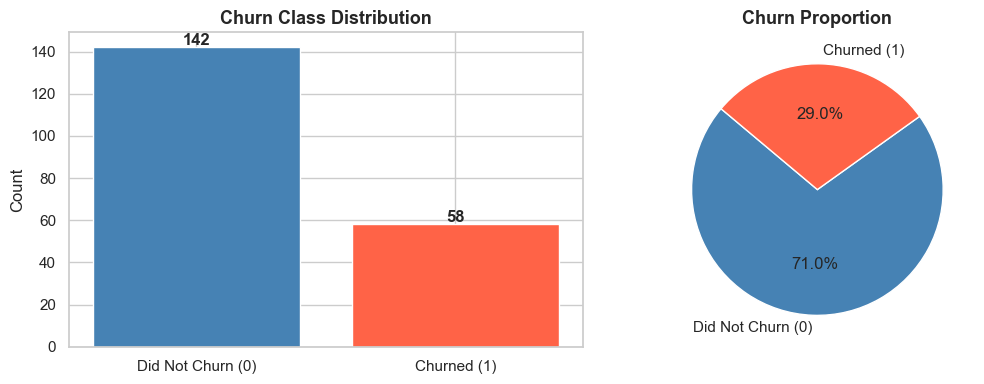


Churn rate: 29.0%


In [7]:
# Visualise class balance — is the dataset imbalanced?
# Class imbalance (e.g. 95% non-churn, 5% churn) affects model performance.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['churn'].value_counts()
labels = ['Did Not Churn (0)', 'Churned (1)']

axes[0].bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Churn Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=140)
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

churn_rate = counts[1] / counts.sum() * 100
print(f"\nChurn rate: {churn_rate:.1f}%")

---
## Step 4 — Feature Selection Using Correlation

**Why select features?**

Including irrelevant features:
- Adds noise → hurts prediction accuracy
- Inflates model complexity → harder to interpret
- Can cause multicollinearity (correlated predictors distort coefficients)

**Strategy:**
1. Compute Pearson correlation of each feature with `churn`
2. Keep features with |correlation| > 0.1 (a reasonable starting threshold)
3. Inspect a heatmap to spot multicollinearity among selected features

> **Note:** Correlation only captures *linear* relationships. For a production model, you'd also use techniques like Recursive Feature Elimination (RFE) or LASSO regularisation.

In [8]:
# ── Step 4a: Correlation with the target ────────────────────────────────────

# We use only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Pearson correlation of every feature with 'churn'
corr_with_churn = numeric_df.corr()['churn'].drop('churn').sort_values(key=abs, ascending=False)

print("Pearson correlation with 'churn' (sorted by absolute value):")
print(corr_with_churn.round(3).to_string())

Pearson correlation with 'churn' (sorted by absolute value):
tenure     -0.377
employ     -0.338
loglong    -0.337
callcard   -0.311
longten    -0.295
longmon    -0.292
age        -0.288
equip       0.275
address    -0.261
equipmon    0.255
internet    0.255
ebill       0.255
cardten    -0.229
ed          0.216
wiremon     0.177
cardmon    -0.177
wireless    0.174
voice       0.142
pager       0.125
lninc      -0.117
income     -0.091
confer     -0.081
logtoll    -0.070
tollten    -0.059
callwait   -0.053
custcat     0.015
tollmon     0.014


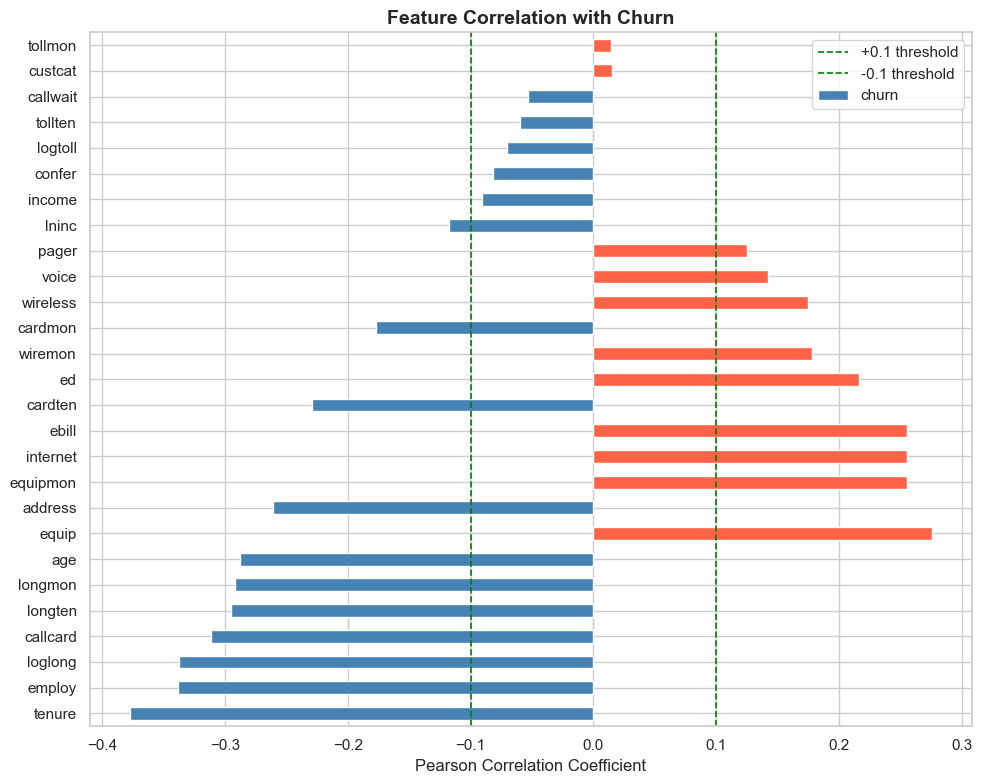

In [9]:
# Visualise the correlations as a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if c > 0 else 'steelblue' for c in corr_with_churn.values]
corr_with_churn.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(x=0.1,  color='green', linestyle='--', linewidth=1.2, label='+0.1 threshold')
ax.axvline(x=-0.1, color='green', linestyle='--', linewidth=1.2, label='-0.1 threshold')
ax.set_title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# ── Step 4b: Apply threshold to select features ──────────────────────────────
THRESHOLD = 0.1

selected_features = corr_with_churn[abs(corr_with_churn) > THRESHOLD].index.tolist()

# Remove 'churn' itself if it slipped in (it shouldn't, but safeguard)
selected_features = [f for f in selected_features if f != 'churn']

print(f"Features selected (|corr| > {THRESHOLD}): {len(selected_features)}")
print(selected_features)

Features selected (|corr| > 0.1): 20
['tenure', 'employ', 'loglong', 'callcard', 'longten', 'longmon', 'age', 'equip', 'address', 'equipmon', 'internet', 'ebill', 'cardten', 'ed', 'wiremon', 'cardmon', 'wireless', 'voice', 'pager', 'lninc']


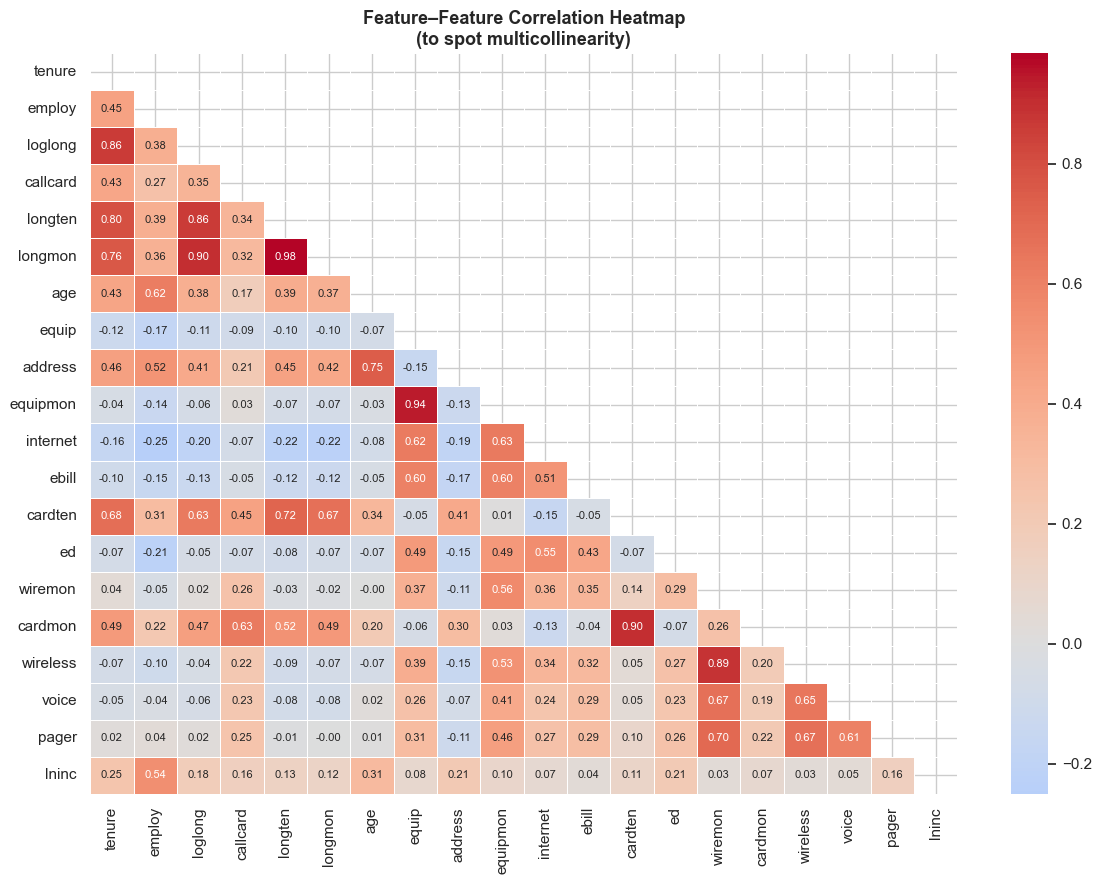


💡 Pairs with |corr| > 0.8 are highly collinear — consider dropping one of each pair.
  loglong      ↔ tenure        r = 0.864
  longten      ↔ loglong       r = 0.863
  longmon      ↔ loglong       r = 0.902
  longmon      ↔ longten       r = 0.985
  equipmon     ↔ equip         r = 0.941
  cardmon      ↔ cardten       r = 0.899
  wireless     ↔ wiremon       r = 0.886


In [11]:
# ── Step 4c: Check multicollinearity among selected features ─────────────────
# If two predictors are highly correlated with EACH OTHER (not just with churn),
# including both adds redundancy. We'll visualise this with a heatmap.

feat_corr = df[selected_features].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(feat_corr, dtype=bool))  # show only lower triangle
sns.heatmap(
    feat_corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature–Feature Correlation Heatmap\n(to spot multicollinearity)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Pairs with |corr| > 0.8 are highly collinear — consider dropping one of each pair.")
high_corr = [
    (feat_corr.columns[i], feat_corr.columns[j], feat_corr.iloc[i, j])
    for i in range(len(feat_corr.columns))
    for j in range(i)
    if abs(feat_corr.iloc[i, j]) > 0.8
]
if high_corr:
    for a, b, r in high_corr:
        print(f"  {a:12s} ↔ {b:12s}  r = {r:.3f}")
else:
    print("  ✅ No highly collinear pairs found among selected features.")

In [12]:
# ── Step 4d: Remove redundant collinear features manually ────────────────────
# 'longmon' and 'loglong' are both log-transforms of long-distance usage.
# 'longten' captures the same dimension (long-distance tenure).
# We keep the more interpretable originals and drop log-transforms
# that duplicate information.

features_to_drop = ['loglong', 'lninc']  # log-transformed duplicates of longmon / income
selected_features = [f for f in selected_features if f not in features_to_drop]

print(f"Final feature set ({len(selected_features)} features):")
for f in selected_features:
    corr_val = corr_with_churn[f]
    direction = '▲ positive' if corr_val > 0 else '▼ negative'
    print(f"  {f:12s}  r={corr_val:+.3f}  {direction}")

Final feature set (18 features):
  tenure        r=-0.377  ▼ negative
  employ        r=-0.338  ▼ negative
  callcard      r=-0.311  ▼ negative
  longten       r=-0.295  ▼ negative
  longmon       r=-0.292  ▼ negative
  age           r=-0.288  ▼ negative
  equip         r=+0.275  ▲ positive
  address       r=-0.261  ▼ negative
  equipmon      r=+0.255  ▲ positive
  internet      r=+0.255  ▲ positive
  ebill         r=+0.255  ▲ positive
  cardten       r=-0.229  ▼ negative
  ed            r=+0.216  ▲ positive
  wiremon       r=+0.177  ▲ positive
  cardmon       r=-0.177  ▼ negative
  wireless      r=+0.174  ▲ positive
  voice         r=+0.142  ▲ positive
  pager         r=+0.125  ▲ positive


---
## Step 5 — Normalisation (Adjusting for Convergence)

**Why normalise?**

Logistic regression is solved via **gradient descent** (or its variants). The algorithm updates weights proportional to the gradient — and gradients are sensitive to feature scale.

- `income` can be 1000+
- `wireless` is binary (0 or 1)

Without normalisation, the optimiser takes huge steps on `income` and tiny steps on `wireless` — causing **slow or failed convergence** (you'll see `ConvergenceWarning`).

**`StandardScaler`** transforms each feature to have:
- Mean = 0
- Standard deviation = 1

Formula: `z = (x - μ) / σ`

> ⚠️ **Important rule:** Fit the scaler on *training data only*, then apply (transform) to both train and test. Fitting on the test set would leak information.

In [13]:
# ── Prepare X (features) and y (target) ─────────────────────────────────────
X = df[selected_features].copy()
y = df['churn']  # already cast to int

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution in y:")
print(y.value_counts())

X shape: (200, 18)
y shape: (200,)

Class distribution in y:
churn
0    142
1     58
Name: count, dtype: int64


In [14]:
# ── Train / Test split BEFORE scaling ────────────────────────────────────────
# We split first so the scaler is fitted only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # preserve class proportions in both splits
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"\nChurn rate in train: {y_train.mean():.1%}")
print(f"Churn rate in test : {y_test.mean():.1%}")

Training set  : 160 samples
Test set      : 40 samples

Churn rate in train: 28.7%
Churn rate in test : 30.0%


In [15]:
# ── Apply StandardScaler ────────────────────────────────────────────────────
scaler = StandardScaler()

# fit_transform on TRAIN — learns μ and σ from training data
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=selected_features
)

# transform only on TEST — uses the μ and σ learned from train
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=selected_features
)

# Verify: means should be ~0, stds should be ~1 for training data
print("Post-scaling training set statistics:")
print(f"  Mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"  Std  (should be ~1): {X_train_scaled.std().mean():.6f}")

Post-scaling training set statistics:
  Mean (should be ~0): 0.000000
  Std  (should be ~1): 1.003140


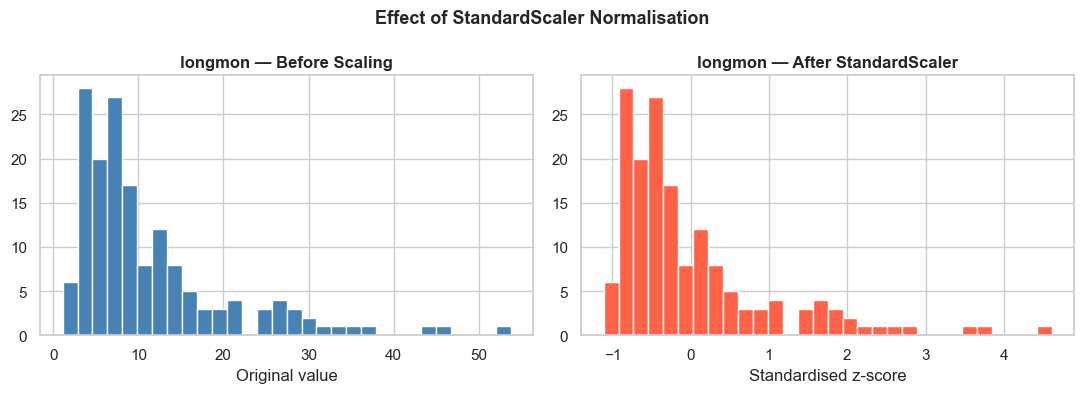

In [16]:
# Visualise before vs after scaling for one feature to build intuition
feature_to_plot = 'longmon'

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

axes[0].hist(X_train[feature_to_plot], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'{feature_to_plot} — Before Scaling', fontweight='bold')
axes[0].set_xlabel('Original value')

axes[1].hist(X_train_scaled[feature_to_plot], bins=30, color='tomato', edgecolor='white')
axes[1].set_title(f'{feature_to_plot} — After StandardScaler', fontweight='bold')
axes[1].set_xlabel('Standardised z-score')

plt.suptitle('Effect of StandardScaler Normalisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6 — Train the Logistic Regression Model

**How logistic regression works:**

Linear regression predicts a continuous value: `ŷ = β₀ + β₁x₁ + β₂x₂ + ...`

Logistic regression wraps that in a **sigmoid function** to produce a probability:

`P(churn=1) = 1 / (1 + e^(-ŷ))`

- Output is always between 0 and 1 ✓
- If P > 0.5 → predict class 1 (churn)
- If P ≤ 0.5 → predict class 0 (no churn)

**`max_iter=1000`** — we give the solver enough iterations to converge. Without normalisation, even 1000 might not be enough.

In [17]:
# ── Instantiate and train the model ─────────────────────────────────────────
model = LogisticRegression(
    max_iter=1000,    # enough iterations for convergence post-scaling
    random_state=42,  # reproducibility
    solver='lbfgs'    # Limited-memory BFGS — efficient for small/medium datasets
)

model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully.")
print(f"   Solver converged: {model.n_iter_[0]} iterations used (max={model.max_iter})")

✅ Model trained successfully.
   Solver converged: 26 iterations used (max=1000)


Logistic Regression Coefficients (log-odds scale):
 Feature  Coefficient
callcard    -0.891404
  employ    -0.709887
 cardmon     0.623543
  tenure    -0.568705
 wiremon     0.425096
   ebill     0.281784
internet     0.268783
     age    -0.260798
 address    -0.182211
 longmon    -0.172773
      ed     0.171245
 longten     0.129496
   equip     0.126929
 cardten    -0.116054
   pager     0.046874
   voice    -0.040074
wireless    -0.027710
equipmon     0.025667


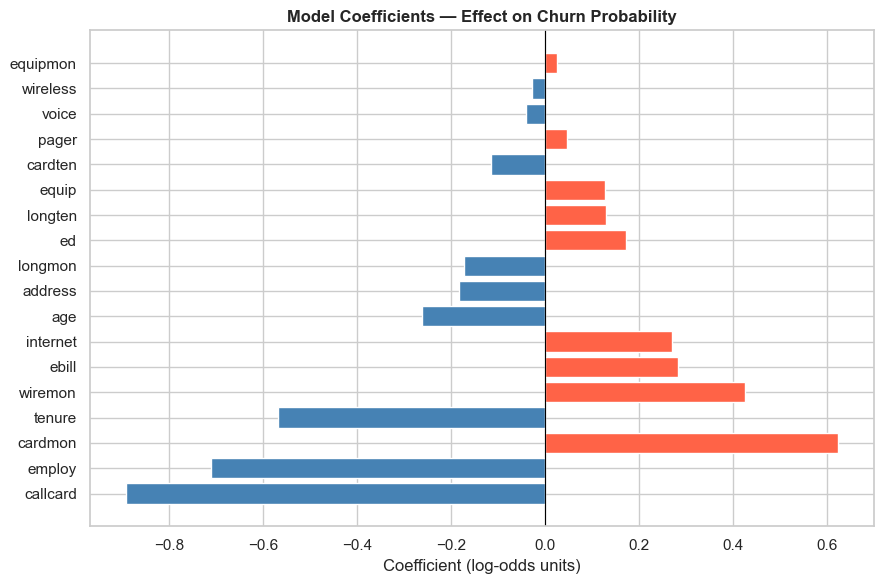

In [18]:
# Inspect the learned coefficients — these tell us the direction & magnitude
# of each feature's contribution to the log-odds of churning.
# Positive coefficient → higher value increases churn probability
# Negative coefficient → higher value decreases churn probability

coef_df = pd.DataFrame({
    'Feature'    : selected_features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Logistic Regression Coefficients (log-odds scale):")
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Model Coefficients — Effect on Churn Probability', fontweight='bold')
ax.set_xlabel('Coefficient (log-odds units)')
plt.tight_layout()
plt.show()

---
## Step 7 — Model Evaluation

### 7a — Loss Function: Log-Loss (Binary Cross-Entropy)

The **loss function** measures how wrong the model is. Logistic regression minimises **log-loss** during training.

Formula:
```
LogLoss = -1/n × Σ [ yᵢ·log(p̂ᵢ) + (1-yᵢ)·log(1-p̂ᵢ) ]
```

- **Lower log-loss = better model**
- A random classifier gives log-loss = 0.693 (ln 2)
- Perfect predictions give log-loss → 0

We report it on *both* train and test sets to check for overfitting.

In [19]:
# ── Get predicted probabilities (needed for log-loss) ────────────────────────
# predict_proba returns [[P(class=0), P(class=1)], ...]
# We want column index 1 — the probability of churning
y_train_prob = model.predict_proba(X_train_scaled)[:, 1]
y_test_prob  = model.predict_proba(X_test_scaled)[:, 1]

# ── Get hard predictions (0 or 1) ────────────────────────────────────────────
y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

# ── Compute log-loss ─────────────────────────────────────────────────────────
train_logloss = log_loss(y_train, y_train_prob)
test_logloss  = log_loss(y_test,  y_test_prob)

print("=" * 45)
print(" LOSS FUNCTION — Binary Cross-Entropy (Log-Loss)")
print("=" * 45)
print(f"  Training log-loss : {train_logloss:.4f}")
print(f"  Test     log-loss : {test_logloss:.4f}")
print(f"  Baseline (random) : 0.6931")
print()
if test_logloss < 0.5:
    print("  ✅ Model is substantially better than random.")
elif test_logloss < 0.65:
    print("  ⚠️  Model is modestly better than random.")
else:
    print("  ❌ Model is near or worse than random — revisit features.")

 LOSS FUNCTION — Binary Cross-Entropy (Log-Loss)
  Training log-loss : 0.3996
  Test     log-loss : 0.5579
  Baseline (random) : 0.6931

  ⚠️  Model is modestly better than random.


AUC-ROC Score : 0.7679


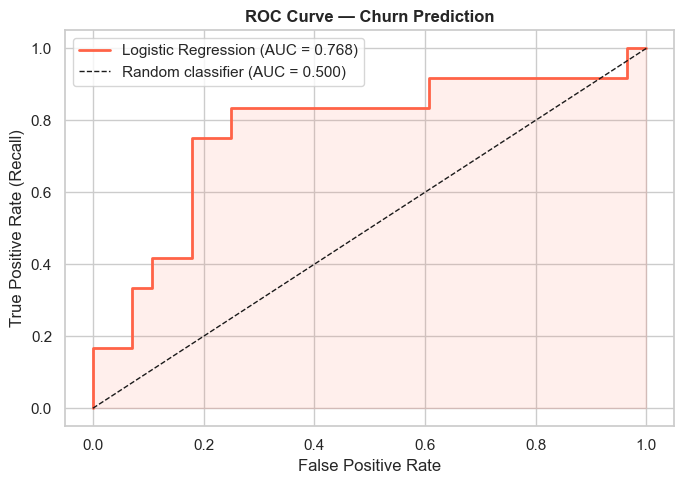

In [20]:
# ── AUC-ROC Score ────────────────────────────────────────────────────────────
# AUC measures the model's ability to rank churners above non-churners.
# AUC = 1.0 → perfect; AUC = 0.5 → random; AUC < 0.5 → worse than random

auc = roc_auc_score(y_test, y_test_prob)
print(f"AUC-ROC Score : {auc:.4f}")

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.1, color='tomato')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Churn Prediction', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

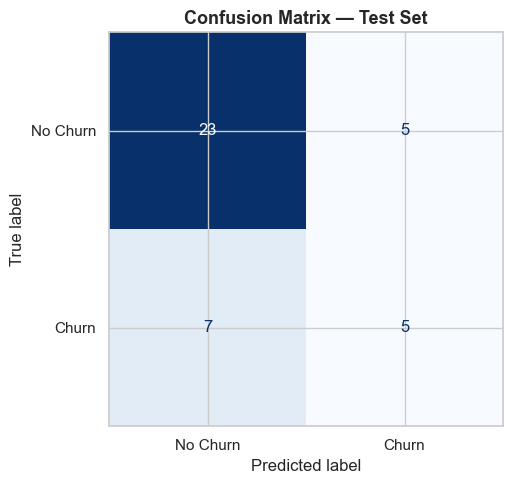

  True Negatives  (correctly identified non-churners): 23
  False Positives (non-churners flagged as churners)  : 5
  False Negatives (churners missed by model)          : 7
  True Positives  (correctly identified churners)     : 5


In [21]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
# Shows actual vs predicted class counts
# True Negatives  | False Positives
# False Negatives | True Positives

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives  (correctly identified non-churners): {tn}")
print(f"  False Positives (non-churners flagged as churners)  : {fp}")
print(f"  False Negatives (churners missed by model)          : {fn}")
print(f"  True Positives  (correctly identified churners)     : {tp}")

In [22]:
# ── Classification Report ────────────────────────────────────────────────────
# Precision: of all predicted churners, how many actually churned?
# Recall   : of all actual churners, how many did we catch?
# F1-score : harmonic mean of precision and recall

print("Classification Report — Test Set")
print("=" * 50)
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

Classification Report — Test Set
              precision    recall  f1-score   support

    No Churn       0.77      0.82      0.79        28
       Churn       0.50      0.42      0.45        12

    accuracy                           0.70        40
   macro avg       0.63      0.62      0.62        40
weighted avg       0.69      0.70      0.69        40



---
## Step 8 — Summary & Interpretation

Let's consolidate everything we did and what we learned.

In [23]:
# ── Final summary dashboard ──────────────────────────────────────────────────
accuracy = (y_test_pred == y_test.values).mean()

print("=" * 55)
print("  CHURN PREDICTION MODEL — FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset           : {df.shape[0]} customers, {df.shape[1]} features")
print(f"  Features used     : {len(selected_features)}")
print(f"  Train / Test split: 80% / 20% (stratified)")
print()
print("  ─── Performance Metrics ───")
print(f"  Test Accuracy  : {accuracy:.1%}")
print(f"  Test Log-Loss  : {test_logloss:.4f}  (lower = better)")
print(f"  Test AUC-ROC   : {auc:.4f}  (1.0 = perfect)")
print()
print("  ─── Key Learnings ───")
top_pos = coef_df[coef_df['Coefficient'] > 0].iloc[0]['Feature']
top_neg = coef_df[coef_df['Coefficient'] < 0].iloc[0]['Feature']
print(f"  Strongest churn predictor (+) : {top_pos}")
print(f"  Strongest retention predictor (-) : {top_neg}")
print()
print("  ─── Steps Taken ───")
print("  1. Loaded 200-customer telecom dataset")
print("  2. Cast 'churn' to integer (categorical for sklearn)")
print("  3. Selected features with |Pearson r| > 0.1")
print("  4. Removed collinear log-transformed duplicates")
print("  5. Normalised with StandardScaler (post train/test split)")
print("  6. Trained LogisticRegression (lbfgs, max_iter=1000)")
print("  7. Evaluated via log-loss, AUC-ROC, confusion matrix")
print("=" * 55)

  CHURN PREDICTION MODEL — FINAL SUMMARY
  Dataset           : 200 customers, 28 features
  Features used     : 18
  Train / Test split: 80% / 20% (stratified)

  ─── Performance Metrics ───
  Test Accuracy  : 70.0%
  Test Log-Loss  : 0.5579  (lower = better)
  Test AUC-ROC   : 0.7679  (1.0 = perfect)

  ─── Key Learnings ───
  Strongest churn predictor (+) : cardmon
  Strongest retention predictor (-) : callcard

  ─── Steps Taken ───
  1. Loaded 200-customer telecom dataset
  2. Cast 'churn' to integer (categorical for sklearn)
  3. Selected features with |Pearson r| > 0.1
  4. Removed collinear log-transformed duplicates
  5. Normalised with StandardScaler (post train/test split)
  6. Trained LogisticRegression (lbfgs, max_iter=1000)
  7. Evaluated via log-loss, AUC-ROC, confusion matrix


---
## 📚 Key Concepts Recap

| Concept | What it is | Why it matters |
|---|---|---|
| **Categorical response** | `churn` as int 0/1 | Required for classification in sklearn |
| **StandardScaler** | Transforms to mean=0, std=1 | Ensures gradient descent converges |
| **Log-loss** | Penalises confident wrong predictions | True loss function optimised during training |
| **AUC-ROC** | Area under the ROC curve | Measures ranking ability regardless of threshold |
| **Confusion matrix** | TP / TN / FP / FN breakdown | Identifies what *type* of errors the model makes |
| **Feature selection** | Keep |r| > 0.1 with target | Reduces noise, improves interpretability |

---

**Next steps to explore:**
- Try `class_weight='balanced'` to address class imbalance
- Use Recursive Feature Elimination (RFE) for more rigorous feature selection
- Add L1 regularisation (`penalty='l1'`) for automatic feature sparsity
- Compare with a Random Forest or XGBoost model